In [1]:
import bonobo
import datetime
import redis
from google.cloud import bigquery
from google.cloud import storage
from google.oauth2 import service_account

In [2]:
credentials = service_account.Credentials.from_service_account_file('SWOO-Analytics-BQ-214c24ac27fb.json')
project_id = 'swoo-analytics-bq'
client = bigquery.Client(credentials= credentials,project=project_id)

In [3]:
QUERY = """
SELECT device_channel,date,body_name
FROM `analytics_data.ua_derived_data_v1`
WHERE type IN ('CUSTOM')
AND body_name IN ('trivia_started_playing', 'bingo_started_playing', 'candyrush_started_playing','swooperstar_gamelandingscreen','teenpatti_started_playing')
and date >= '2019-03-25' and date <= '2019-03-31'
GROUP BY 1,2,3  """

In [4]:
from pandas.io import gbq
df = gbq.read_gbq(QUERY,project_id = 'swoo-analytics-bq',dialect = "standard")
df.head()

,device_channel,date,body_name
0,fc65f768-b84e-4a38-aa59-88a53b2a851a,2019-03-25,bingo_started_playing
1,18129758-b951-4fb1-8cee-ac456dc1418d,2019-03-25,teenpatti_started_playing
2,34dda004-e161-42cf-8981-405b37bdd5e2,2019-03-25,bingo_started_playing
3,09a3985c-5ea0-4a07-8587-ac197ea184c9,2019-03-25,teenpatti_started_playing
4,92e0c07e-40ba-44f6-ae7c-28481833e591,2019-03-25,trivia_started_playing


In [5]:
df.shape

(845537, 3)

In [6]:
df.drop_duplicates(subset=['date','device_channel','body_name'],keep = 'first', inplace=True)

In [7]:
df.shape

(845537, 3)

In [8]:
df.groupby(['body_name'])['device_channel'].count()

body_name
bingo_started_playing            366337
candyrush_started_playing        219173
swooperstar_gamelandingscreen     63886
teenpatti_started_playing        129696
trivia_started_playing            66445
Name: device_channel, dtype: int64

In [9]:
import pandas as pd
bingo = pd.DataFrame()
bingo['device_channel'] = df['device_channel'][df['body_name'] == "bingo_started_playing"]
Trivia = pd.DataFrame()
Trivia['device_channel'] = df['device_channel'][df['body_name'] == "trivia_started_playing"]
CandyRush = pd.DataFrame()
CandyRush['device_channel'] = df['device_channel'][df['body_name'] == "candyrush_started_playing"]
SwooperStar = pd.DataFrame()
SwooperStar['device_channel'] = df['device_channel'][df['body_name'] == "swooperstar_gamelandingscreen"]
TeenPatti = pd.DataFrame()
TeenPatti['device_channel'] = df['device_channel'][df['body_name'] == "teenpatti_started_playing"]

In [10]:
bingo1 = []
Trivia1 = []
CandyRush1 = []
SwooperStar1 = []
bingo1 = set(bingo['device_channel'])
Trivia1 = set(Trivia['device_channel'])
CandyRush1 = set(CandyRush['device_channel'])
SwooperStar1 = set(SwooperStar['device_channel'])
TeenPatti1 = set(TeenPatti['device_channel'])

/Users/yaswanth/anaconda3/lib/python3.7/site-packages/venn/_backwards_compatibility.py:16: UserWarning: `get_labels()` is retained for backwards compatibility; use `generate_petal_labels()` or the higher level `venn()` instead
  "`get_labels()` is retained for backwards compatibility; " +
/Users/yaswanth/anaconda3/lib/python3.7/site-packages/venn/_backwards_compatibility.py:32: UserWarning: `venn5()` is retained for backwards compatibility; use `venn()` instead
  "use `venn()` instead"
/Users/yaswanth/anaconda3/lib/python3.7/site-packages/matplotlib/figure.py:457: UserWarning: matplotlib is currently using a non-GUI backend, so cannot show the figure
  "matplotlib is currently using a non-GUI backend, "


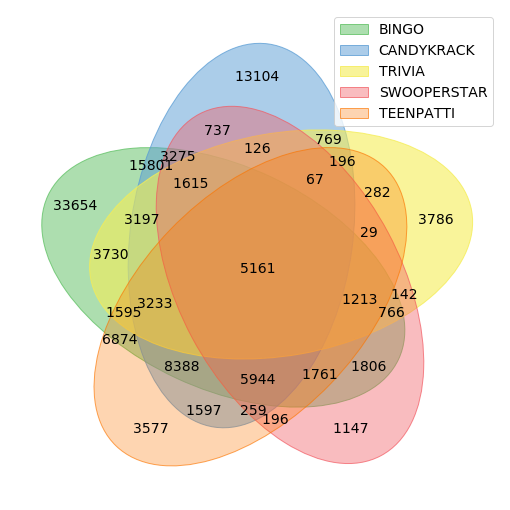

In [13]:
import matplotlib.pyplot as plt
import venn
labels = venn.get_labels([bingo1,CandyRush1,Trivia1,SwooperStar1,TeenPatti1])
fig, ax = venn.venn3(labels, names=['BINGO', 'CANDYKRACK', 'TRIVIA','SWOOPERSTAR','TEENPATTI'])
plt.savefig('game2134567')
fig.show()

In [12]:
import os
os.getcwd()

'/Users/yaswanth/Downloads'